# Aula 02 — Métodos Baseados em Valores


## Notebook 02 — Monte Carlo, TD(0) e Q-Learning



**Disciplina:** Modelos de Aprendizagem por Reforço  
**Tema:** Aprendizado model-free, bootstrapping, controle tabular  
**Ambiente:** FrozenLake-v1 (`is_slippery=True`)

## Informações do notebook

| Item | Detalhe |
|---|---|
| **Aula** | Aula 02 — Métodos Baseados em Valores |
| **Notebook** | 02 — Monte Carlo, TD(0) e Q-Learning |
| **Seções** | 2.4, 2.5 |
| **Tempo de leitura** | 20 min |
| **Tempo de execução (padrão)** | 4 min |
| **Exercícios** | 3 questões de autoavaliação |

### Pré-requisitos

- **Notebooks anteriores:** `01_valor_bellman_dp.ipynb` — Equação de Bellman e Programação Dinâmica.
- **Conceitos:** função de valor V(s), Q(s,a), política ε-greedy.

### Competências para o Desafio Final

- Implementar Monte Carlo first-visit, TD(0) e Q-Learning em ambiente model-free.
- Distinguir o mecanismo de bootstrapping do retorno completo de episódio.
- Comparar estimativas de V(s) e Q(s,a) produzidas por cada método.

### Recapitulando

No notebook anterior, a **Programação Dinâmica** calculou V*(s) exato no GridWorld — porque o modelo completo estava disponível (transições, recompensas).

A limitação central: em problemas reais o modelo raramente existe.

Este notebook aprende por interação, sem modelo.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import rl_utils
rl_utils.info_versoes()
rl_utils.configurar_matplotlib()
rl_utils.definir_seeds(42)

Biblioteca           Versão
--------------------------------
gymnasium            1.0.0
torch                2.11.0+cpu
numpy                2.4.2
matplotlib           3.10.8
pandas               3.0.1
scikit-learn         1.8.0


## Bloco 1 — Contexto e pergunta



No notebook anterior, os valores foram calculados de forma exata porque o modelo do ambiente estava disponível.

Em problemas reais, esse modelo raramente existe.

A pergunta que guia este notebook é:

> **Como um agente aprende funções de valor quando não conhece o modelo do ambiente?**

A resposta: aprendendo a partir de experiências — episódios de interação com o ambiente.

Dois mecanismos principais surgem dessa ideia:

- **Monte Carlo:** espera o episódio terminar e usa o retorno completo observado como alvo de atualização.
- **TD(0) (Temporal-Difference):** atualiza a estimativa a cada passo, usando a recompensa imediata e a estimativa do próximo estado — isso é chamado de *bootstrapping*.
- **Q-Learning:** estende o TD ao controle, estimando diretamente Q(s,a) com um alvo *off-policy*.

**Mensagem principal:**
> *Monte Carlo espera o fim do episódio; TD aprende a cada passo com bootstrapping.*

In [2]:
# Instalação opcional das dependências
# %pip install gymnasium numpy matplotlib

In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Versões utilizadas:")
print("numpy:", np.__version__)
print("gymnasium:", gym.__version__)
print("matplotlib:", plt.matplotlib.__version__)

Versões utilizadas:
numpy: 2.4.2
gymnasium: 1.0.0
matplotlib: 3.10.8


## Inspeção do ambiente



O FrozenLake-v1 em modo escorregadio introduz estocasticidade: o agente escolhe uma direção, mas o resultado pode diferir. Essa incerteza torna a comparação entre Monte Carlo e TD(0) mais reveladora, pois a variância dos retornos se torna mais visível.

O ambiente utilizado será o `FrozenLake-v1` em modo escorregadio (`is_slippery=True`). Nesse ambiente, o agente se desloca em uma grade 4×4, partindo do estado inicial `S` e tentando alcançar o objetivo `G`, evitando os buracos `H`.

A característica mais importante deste experimento é a estocasticidade. Mesmo quando o agente escolhe uma direção, o resultado pode não ser exatamente o esperado, porque o gelo é escorregadio. Isso torna o ambiente mais realista do ponto de vista de Reinforcement Learning: a mesma ação em um mesmo estado pode gerar consequências diferentes em episódios distintos.

Essa incerteza é útil para comparar Monte Carlo e TD(0). Como Monte Carlo depende do retorno completo do episódio, suas estimativas podem oscilar bastante em ambientes estocásticos. Já TD(0) atualiza a cada transição, usando uma estimativa parcial do futuro, o que tende a produzir aprendizado mais incremental.

In [4]:
env = gym.make("FrozenLake-v1", is_slippery=True)
obs, info = env.reset(seed=SEED)

print("Espaço de estados:", env.observation_space)
print("Número de estados:", env.observation_space.n)
print("Espaço de ações:", env.action_space)
print("Observação inicial:", obs)

desc = env.unwrapped.desc.astype(str)
print("\nMapa do FrozenLake (S=início, G=objetivo, H=buraco, F=gelo):")
for row in desc:
    print(" ".join(row))

Espaço de estados: Discrete(16)
Número de estados: 16
Espaço de ações: Discrete(4)
Observação inicial: 0

Mapa do FrozenLake (S=início, G=objetivo, H=buraco, F=gelo):
S F F F
F H F H
F F F H
H F F G


O mapa exibido pelo notebook mostra 16 estados discretos. O agente começa no canto superior esquerdo e precisa alcançar o objetivo no canto inferior direito. Os buracos encerram o episódio com falha.

A recompensa positiva só aparece quando o agente chega ao objetivo. Isso torna o problema desafiador, pois durante a maior parte do treinamento o agente observa muitas transições com recompensa zero. Em outras palavras, o sinal de aprendizado é esparso.

Essa esparsidade ajuda a explicar por que os valores estimados no início tendem a ser pequenos. Para que um estado receba valor alto, o agente precisa descobrir, por experiência, que aquele estado pode conduzir ao objetivo. O aprendizado consiste justamente em propagar essa informação para estados anteriores.

---

**Métodos com modelo vs. métodos sem modelo**

| Família | O que conhece | Como aprende |
|---|---|---|
| Programação Dinâmica (NB01) | `P(s'\|s,a)` e `R(s,a)` completos | Calcula valores exatos sem interagir com o ambiente |
| Monte Carlo / TD / Q-Learning (este notebook) | Não conhece `P` nem `R` | Aprende de episódios de interação real |

No notebook anterior, a DP tinha acesso ao **modelo completo**: sabia exatamente para onde cada ação levaria e qual recompensa receberia. Os métodos deste notebook aprendem **interagindo** — observando sequências `(s, a, r, s')` passo a passo, sem nunca ver `P` ou `R` explicitamente. Essa é a distinção que torna Monte Carlo, TD e Q-Learning aplicáveis a problemas reais.

## Bloco 2 — Mini teoria: alvos de atualização

**Notação usada nesta seção:**

- **G_t** = retorno descontado a partir do passo t: $G_t = r_{t+1} + γ·r_{t+2} + γ²·r_{t+3} + ...$ (soma de todas as recompensas futuras, ponderadas por γ)
- **α** = taxa de aprendizado — quanto cada atualização altera a estimativa atual (0 < α ≤ 1)
- **max_a' Q(s', a')** = o maior Q-value entre todas as ações possíveis no próximo estado s' — representa a melhor ação que o agente *poderia* tomar, independentemente do que vai tomar de fato



A diferença fundamental entre os três métodos está no que é usado como **alvo de atualização**:

| Método | Alvo de atualização | Quando atualiza |
|---|---|---|
| Monte Carlo | G_t = r_{t+1} + γ·r_{t+2} + ... (retorno completo) | Após o fim do episódio |
| TD(0) | r_{t+1} + γ·V(s_{t+1}) (bootstrapping) | A cada passo |
| Q-Learning | r_{t+1} + γ·max_a' Q(s_{t+1}, a') (off-policy) | A cada passo |

**Bootstrapping** significa corrigir uma estimativa usando outra estimativa — o TD usa V(s_{t+1}) antes de saber o retorno real. Monte Carlo não faz isso; ele espera o valor real do retorno completo.

A diferença central entre Monte Carlo, TD(0) e Q-Learning está no alvo usado para atualizar as estimativas.

No Monte Carlo, o alvo é o retorno completo observado depois que o episódio termina:

$
G_t = r_{t+1} + \gamma r_{t+2} + \gamma^2 r_{t+3} + \cdots
$

No TD(0), o alvo é construído a partir de uma transição local:

$
r_{t+1} + \gamma V(s_{t+1})
$

No Q-Learning, o alvo passa a envolver valores de ação:

$
r_{t+1} + \gamma \max_{a'} Q(s_{t+1}, a')
$

Essa diferença altera profundamente o comportamento dos algoritmos. Monte Carlo espera o fim do episódio e usa uma observação completa do retorno. TD(0) aprende antes do fim, usando bootstrapping. Q-Learning usa bootstrapping sobre \(Q(s,a)\) e já aprende uma estrutura diretamente ligada à escolha de ações.

In [5]:
print("Alvo em Monte Carlo (retorno completo):")
print("  G_t = r_{t+1} + gamma*r_{t+2} + gamma^2*r_{t+3} + ...")
print()
print("Alvo em TD(0) (bootstrapping sobre V(s)):")
print("  delta_t = r_{t+1} + gamma*V(s_{t+1}) - V(s_t)")
print("  V(s_t) <- V(s_t) + alpha*delta_t")
print()
print("Alvo em Q-Learning (bootstrapping sobre Q(s,a), off-policy):")
print("  delta_t = r_{t+1} + gamma*max_a' Q(s_{t+1},a') - Q(s_t,a_t)")
print("  Q(s_t,a_t) <- Q(s_t,a_t) + alpha*delta_t")

Alvo em Monte Carlo (retorno completo):
  G_t = r_{t+1} + gamma*r_{t+2} + gamma^2*r_{t+3} + ...

Alvo em TD(0) (bootstrapping sobre V(s)):
  delta_t = r_{t+1} + gamma*V(s_{t+1}) - V(s_t)
  V(s_t) <- V(s_t) + alpha*delta_t

Alvo em Q-Learning (bootstrapping sobre Q(s,a), off-policy):
  delta_t = r_{t+1} + gamma*max_a' Q(s_{t+1},a') - Q(s_t,a_t)
  Q(s_t,a_t) <- Q(s_t,a_t) + alpha*delta_t


---



## Seção 1 / 3 — Monte Carlo First-Visit

**Mecanismo central:** aguardar o episódio terminar, calcular o retorno completo $G_t$ para cada estado visitado, e atualizar ao final.

$$V(s_t) \leftarrow V(s_t) + \alpha \cdot (G_t - V(s_t)) \qquad \text{(após o episódio)}$$

Na variante *first-visit*, cada estado é atualizado apenas na **primeira** ocorrência no episódio. O alvo $G_t = r_{t+1} + \gamma r_{t+2} + \cdots$ é o retorno real observado — sem bootstrapping.

**O que observar:** (a) `gerar_episodio` coleta o trajeto completo antes de qualquer atualização; (b) o loop `for t in reversed(range(...))` propaga os retornos do fim para o início.


O método Monte Carlo estima valores a partir de episódios completos. A variante *first-visit* atualiza cada estado apenas na primeira vez em que ele aparece dentro de um episódio.

A lógica é a seguinte:

1. o agente executa um episódio completo;
2. ao final, calcula o retorno acumulado de cada ponto da trajetória;
3. atualiza \(V(s)\) aproximando o valor atual do retorno observado;
4. repete esse processo por muitos episódios.

A atualização pode ser escrita como:

$
V(s_t) \leftarrow V(s_t) + \alpha \left(G_t - V(s_t)\right)
$

O ponto essencial é que Monte Carlo não usa bootstrapping. Ele não atualiza \(V(s)\) com base em outra estimativa de valor, mas sim com base no retorno completo observado no episódio.

In [6]:
def gerar_episodio(env, seed=None):
    """Coleta um episódio com política aleatória (para predição de V(s))."""
    estados, recompensas = [], []
    # seed=None permite aleatoriedade entre episódios; seed fixo garante reprodutibilidade
    estado, _ = env.reset(seed=seed)
    encerrado = False
    while not encerrado:
        acao = env.action_space.sample()  # política aleatória uniforme
        prox_estado, recompensa, terminado, truncado, _ = env.step(acao)
        estados.append(estado)
        recompensas.append(recompensa)
        estado = prox_estado
        encerrado = terminado or truncado
    return estados, recompensas


def treinar_monte_carlo(env, episodios=6000, gamma=0.99, alpha=0.03):
    """Estima V(s) por Monte Carlo first-visit com política aleatória."""
    V = np.zeros(env.observation_space.n, dtype=float)
    retornos_log = []
    for ep in range(episodios):
        estados, recompensas = gerar_episodio(env, seed=SEED + ep)
        G = 0.0
        visitados = set()
        # Percorre o episódio de trás para frente para calcular o retorno acumulado G
        # Essa ordem permite reutilizar G do passo seguinte: G = r_t + gamma * G_{t+1}
        for t in reversed(range(len(recompensas))):
            G = recompensas[t] + gamma * G
            s = estados[t]
            # First-visit MC: atualiza V(s) apenas na PRIMEIRA vez que s aparece no episódio
            # Distingue-se do every-visit MC, que atualizaria todas as ocorrências
            if s not in visitados:
                visitados.add(s)
                V[s] += alpha * (G - V[s])
        retornos_log.append(float(np.sum(recompensas)))
    return V, np.array(retornos_log)


V_mc, log_mc = treinar_monte_carlo(env)
print("V(s) estimado por Monte Carlo (grid 4x4):")
print(np.round(V_mc.reshape(4, 4), 3))

V(s) estimado por Monte Carlo (grid 4x4):
[[0.001 0.003 0.001 0.001]
 [0.005 0.    0.008 0.   ]
 [0.029 0.053 0.082 0.   ]
 [0.    0.126 0.393 0.   ]]


**Resultado — Monte Carlo:** V(s) estimado após 6 000 episódios com política aleatória. Estados mais próximos do objetivo têm valor maior. No FrozenLake escorregadio, o mesmo estado pode produzir retornos muito diferentes em episódios distintos — isso se manifesta como alta variância nas estimativas, visível na textura do heatmap da Seção de comparação adiante.

A tabela de \(V(s)\) estimada por Monte Carlo mostra valores mais altos em estados que, sob a política aleatória usada para coleta, têm maior chance de conduzir ao objetivo. O maior valor aparece próximo ao objetivo, especialmente no estado imediatamente anterior a `G`.

No resultado exibido, a região inferior direita concentra os maiores valores, enquanto os buracos e estados terminais permanecem com valor zero. Isso está de acordo com a estrutura do FrozenLake: estados próximos ao objetivo tendem a ser mais promissores, desde que não levem diretamente a buracos.

Ao mesmo tempo, os valores permanecem relativamente baixos. Isso ocorre porque a política usada para estimar \(V(s)\) é aleatória. O agente ainda não está tentando agir de forma ótima; ele apenas coleta episódios e estima o valor esperado dos estados sob esse comportamento. Em um ambiente escorregadio e com recompensa esparsa, alcançar o objetivo por acaso não é frequente, o que reduz os valores médios estimados.

O Monte Carlo trabalha com retornos completos. Isso significa que uma única trajetória pode afetar bastante a estimativa de valor de vários estados visitados.

No FrozenLake escorregadio, duas trajetórias que passam pelo mesmo estado podem ter finais completamente diferentes: uma pode alcançar o objetivo, enquanto outra pode cair em um buraco. Como o retorno completo depende de todo o restante do episódio, o alvo de atualização pode variar bastante.

Essa é a principal característica prática do Monte Carlo: ele usa um alvo empiricamente completo, mas ruidoso. Por isso, muitas vezes exige grande número de episódios para produzir estimativas estáveis.

---



## Seção 2 / 3 — TD(0) — Diferença Temporal



**Mecanismo central:** atualizar $V(s)$ a cada passo usando *bootstrapping* — sem esperar o episódio terminar.

$$V(s_t) \leftarrow V(s_t) + \alpha \cdot (r_{t+1} + \gamma V(s_{t+1}) - V(s_t)) \qquad \text{(a cada transição)}$$

O alvo $r_{t+1} + \gamma V(s_{t+1})$ usa a estimativa atual de $V(s')$ antes de conhecer o retorno real. Isso é *bootstrapping*: corrigir uma estimativa usando outra estimativa.

**O que observar:** (a) a atualização ocorre *dentro* do loop de passos, não após; (b) o alvo usa `V[prox_estado]`, não o retorno acumulado.

O TD(0), ou Temporal Difference, atualiza valores a cada passo. Em vez de esperar o fim do episódio, o agente usa a transição observada imediatamente:

$
s_t \rightarrow s_{t+1}
$

A atualização é dada por:

$
V(s_t) \leftarrow V(s_t) + \alpha \left[r_{t+1} + \gamma V(s_{t+1}) - V(s_t)\right]
$

O termo entre colchetes é o erro TD. Ele mede a diferença entre o valor atual de \(s_t\) e o alvo formado pela recompensa imediata mais o valor estimado do próximo estado.

A principal diferença em relação ao Monte Carlo é que TD(0) aprende antes de saber o retorno final do episódio. Isso torna o método mais incremental e geralmente mais eficiente em problemas em que esperar o fim do episódio é caro ou pouco informativo.

In [7]:
def treinar_td0(env, episodios=6000, gamma=0.99, alpha=0.05):
    """Estima V(s) com TD(0), atualizando a cada passo por bootstrapping."""
    V = np.zeros(env.observation_space.n, dtype=float)
    retornos_log = []
    for ep in range(episodios):
        estado, _ = env.reset(seed=SEED + ep)
        encerrado = False
        total = 0.0
        while not encerrado:
            acao = env.action_space.sample()  # política aleatória uniforme
            prox_estado, recompensa, terminado, truncado, _ = env.step(acao)
            encerrado = terminado or truncado
            # Alvo TD: recompensa imediata + valor descontado do próximo estado (bootstrapping)
            # Quando o episódio encerra (encerrado=True), não há valor futuro a propagar:
            # multiplica V[prox_estado] por 0 para anular o termo futuro
            alvo_td = recompensa + gamma * V[prox_estado] * (0 if encerrado else 1)
            V[estado] += alpha * (alvo_td - V[estado])
            estado = prox_estado
            total += recompensa
        retornos_log.append(total)
    return V, np.array(retornos_log)


V_td, log_td = treinar_td0(env)
print("V(s) estimado por TD(0) (grid 4x4):")
print(np.round(V_td.reshape(4, 4), 3))

V(s) estimado por TD(0) (grid 4x4):
[[0.013 0.012 0.02  0.007]
 [0.011 0.    0.049 0.   ]
 [0.024 0.066 0.099 0.   ]
 [0.    0.145 0.391 0.   ]]


**Resultado — TD(0):** V(s) estimado com a mesma política aleatória. As estimativas tendem a ser mais uniformes do que Monte Carlo porque cada atualização usa apenas um passo de ruído em vez do ruído acumulado do episódio inteiro. O custo: viés de bootstrapping — $V(s')$ é uma estimativa, não o valor real.


A tabela de \(V(s)\) estimada por TD(0) apresenta uma estrutura semelhante à de Monte Carlo: valores mais altos aparecem em regiões que podem conduzir ao objetivo, especialmente na parte inferior direita do mapa.

No resultado exibido, o estado próximo ao objetivo também recebe valor elevado, e alguns estados intermediários apresentam valores ligeiramente maiores do que no Monte Carlo. Isso acontece porque TD(0) propaga estimativas de valor de forma incremental. Assim que um estado começa a receber valor, esse valor já pode influenciar estados anteriores.

Essa é a força do bootstrapping: o agente não precisa esperar por muitos episódios completos de sucesso para começar a ajustar estados intermediários. O custo é que a atualização depende de estimativas que ainda podem estar imprecisas.

## Comparação entre Monte Carlo e TD(0)



Monte Carlo e TD(0) resolvem um problema parecido: estimar \(V(s)\) sob uma política de comportamento. A diferença está na fonte do alvo de atualização.

Monte Carlo usa o retorno completo. Isso reduz o viés do alvo, mas aumenta a variância, especialmente em ambientes estocásticos.

TD(0) usa a recompensa imediata e a estimativa do próximo estado. Isso reduz a dependência do episódio completo e permite aprendizado passo a passo, mas introduz viés porque a estimativa futura ainda pode estar errada.

No FrozenLake, os dois métodos identificam a mesma estrutura geral do ambiente: estados próximos ao objetivo tendem a ter maior valor. A diferença está no modo como essa informação se propaga e na estabilidade das estimativas ao longo do treinamento.

---


## Seção 3 / 3 — Q-Learning — Controle Off-Policy

O **TD(0)** é o ponto de partida: ele aprende a função de valor de estado $V(s)$ atualizando a estimativa atual com base na próxima observação, sem esperar o fim do episódio. A regra de atualização é:

$$
V(s_t) \leftarrow V(s_t) + \alpha \left[ r_{t+1} + \gamma V(s_{t+1}) - V(s_t) \right]
$$

A ideia central é o **bootstrapping**: o agente corrige sua estimativa atual usando uma estimativa subsequente, ponderada pelo erro temporal $\delta_t = r_{t+1} + \gamma V(s_{t+1}) - V(s_t)$.

Para que o agente possa **escolher ações** sem precisar de um modelo do ambiente, não basta saber o valor de cada estado; é preciso saber o valor de cada par estado-ação. Assim, em vez de aprender $V(s)$, passa-se a aprender $Q(s,a)$, aplicando a mesma lógica de TD(0):

$$
Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \left[ r_{t+1} + \gamma \, Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t) \right]
$$

Essa atualização corresponde ao **SARSA**, que é on-policy: o alvo usa a ação $a_{t+1}$ que de fato será executada pela política atual.

O **Q-Learning** introduz uma única — porém decisiva — modificação. Em vez de usar a ação $a_{t+1}$ realmente escolhida, utiliza-se a **melhor ação possível** segundo a estimativa atual de $Q$:

$$
Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \left[ r_{t+1} + \gamma \max_{a'} Q(s_{t+1}, a') - Q(s_t, a_t) \right]
$$

Esse pequeno detalhe — substituir $Q(s_{t+1}, a_{t+1})$ por $\max_{a'} Q(s_{t+1}, a')$ — torna o método **off-policy**: o agente pode explorar com uma política qualquer (por exemplo, $\varepsilon$-greedy) enquanto aprende, em paralelo, a política ótima determinística.


| Etapa | Atualiza | Política do alvo | Tipo |
|---|---|---|---|
| TD(0) | $V(s)$ | a mesma do agente | on-policy (predição) |
| SARSA | $Q(s,a)$ | a mesma do agente | on-policy (controle) |
| Q-Learning | $Q(s,a)$ | a gulosa ($\max_{a'}$) | off-policy (controle) |

Em síntese, o Q-Learning herda do TD(0) o mecanismo de bootstrapping e o aprendizado incremental, mas reorganiza esses ingredientes em torno de $Q(s,a)$ e troca o alvo amostrado pelo alvo gulos, abrindo caminho para o aprendizado off-policy que sustentará, mais adiante, algoritmos como o DQN.

**Mecanismo central:** estender o TD ao *controle* — aprender $Q(s,a)$ diretamente, com alvo *off-policy* usando `max`.

$$Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \cdot (r_{t+1} + \gamma \max_{a'} Q(s_{t+1}, a') - Q(s_t, a_t))$$

O alvo usa $\max_{a'} Q(s', a')$ — o valor da melhor ação em $s'$ — independentemente da ação que a política $\varepsilon$-greedy vai executar. O agente aprende sobre a política ótima **enquanto ainda explora**.

**Por que o ε precisa decair?** No início do treinamento, a Q-table está zerada — exploração intensa é essencial para descobrir quais ações valem mais. Ao final, continuar agindo aleatoriamente desperdiça o que foi aprendido: com ε fixo em 1.0 por todo o treinamento, a política nunca melhora porque as ações gulosas nunca são executadas. O decaimento equilibra: explorar no início, explotar ao final.

**O que observar:** (a) `epsilon_greedy` decide *qual ação executar*; (b) o alvo usa `np.max(Q[prox_estado])` — a ação ótima, não a executada; (c) o $\varepsilon$ decai ao longo dos episódios.

In [8]:
def epsilon_greedy(Q, estado, epsilon, n_acoes):
    if random.random() < epsilon:
        return random.randrange(n_acoes)
    return int(np.argmax(Q[estado]))


def treinar_qlearning(env, episodios=6000, alpha=0.1, gamma=0.99,
                      eps_inicio=1.0, eps_fim=0.05, eps_decaimento=0.999):
    """Aprende Q(s,a) com Q-Learning off-policy e política ε-greedy."""
    n_s = env.observation_space.n
    n_a = env.action_space.n
    Q = np.zeros((n_s, n_a), dtype=float)
    retornos_log = []
    eps = eps_inicio
    for ep in range(episodios):
        estado, _ = env.reset(seed=SEED + ep)
        encerrado = False
        total = 0.0
        while not encerrado:
            acao = epsilon_greedy(Q, estado, eps, n_a)
            prox_estado, recompensa, terminado, truncado, _ = env.step(acao)
            encerrado = terminado or truncado
            # Off-policy: o alvo usa np.max(Q[prox_estado]), a ação ótima hipotética no próximo estado
            # O agente aprende como se sempre agisse de forma gulosa a partir dali,
            # independentemente da ação exploratória que a política ε-greedy vai de fato executar
            alvo = recompensa + gamma * np.max(Q[prox_estado]) * (0 if encerrado else 1)
            Q[estado, acao] += alpha * (alvo - Q[estado, acao])
            estado = prox_estado
            total += recompensa
        retornos_log.append(total)
        eps = max(eps_fim, eps * eps_decaimento)
    return Q, np.array(retornos_log)


Q_ql, log_ql = treinar_qlearning(env)
V_ql = np.max(Q_ql, axis=1)  # V(s) derivado do maximo Q(s,a)
print("V(s) derivado de Q-Learning (grid 4x4):")
print(np.round(V_ql.reshape(4, 4), 3))

V(s) derivado de Q-Learning (grid 4x4):
[[0.512 0.456 0.378 0.388]
 [0.525 0.    0.222 0.   ]
 [0.567 0.641 0.596 0.   ]
 [0.    0.778 0.873 0.   ]]


O resultado do Q-Learning deve ser lido de forma diferente dos resultados de Monte Carlo e TD(0). Agora, o agente não está apenas estimando o valor dos estados sob uma política aleatória. Ele está aprendendo valores de ação, isto é, uma base para decidir o que fazer em cada estado.

A curva de recompensa ao longo dos episódios mostra se o agente está aumentando a frequência com que alcança o objetivo. Em ambientes como FrozenLake escorregadio, essa curva pode oscilar bastante, pois mesmo uma política razoável pode falhar por causa da estocasticidade do ambiente.

A média móvel ajuda a visualizar a tendência geral por trás dessas oscilações. Se a média móvel cresce ao longo do treinamento, isso indica que o agente está encontrando, com mais frequência, trajetórias que levam ao objetivo.

A política final extraída da tabela \(Q(s,a)\) representa a escolha gulosa do agente: em cada estado, seleciona-se a ação com maior valor estimado. Essa política não é garantidamente perfeita em poucas execuções, mas deve refletir o conhecimento acumulado pelo agente durante o treinamento.

## Bloco 3 — Heatmaps comparativos das estimativas de valor

Os três heatmaps abaixo mostram as estimativas de V(s) ao final do treinamento. Monte Carlo e TD usam política aleatória (predição), enquanto Q-Learning usa política ε-gulosa (controle). As diferenças entre os heatmaps refletem tanto a distinção entre os mecanismos de atualização quanto os objetivos diferentes (predição vs controle).

> ⚠️ **Atenção na leitura comparativa:** Monte Carlo e TD(0) estimam V(s) sob **política aleatória** (tarefa de predição). Q-Learning aprende Q(s,a) com **política ε-greedy** (tarefa de controle). Os valores não são diretamente comparáveis — Q-Learning produz valores maiores por natureza, pois refletem uma política que evolui para ser melhor que aleatória.

Os heatmaps permitem comparar visualmente as estimativas produzidas por Monte Carlo e TD(0). Cada célula representa o valor estimado de um estado do FrozenLake.

Na leitura desses gráficos, valores mais altos indicam estados mais promissores sob a política usada na coleta de experiências. Valores baixos indicam estados pouco úteis, perigosos ou associados a baixa probabilidade de alcançar o objetivo.

É importante interpretar os heatmaps em conjunto com o mapa do ambiente. Um estado próximo ao objetivo tende a ter valor alto, mas essa relação pode ser afetada pela presença de buracos e pela estocasticidade do gelo. Portanto, o valor de um estado não depende apenas da distância até o objetivo, mas também do risco das transições ao redor.

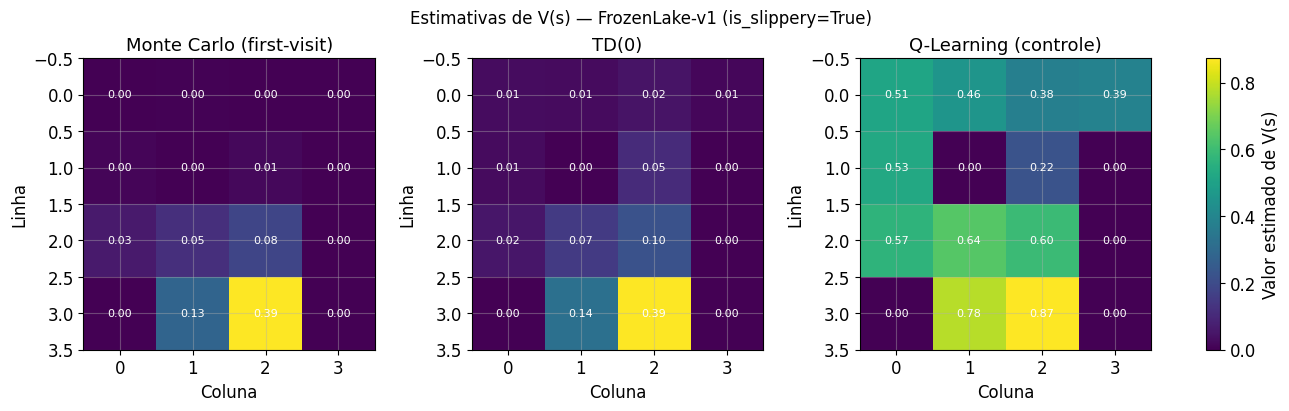

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)

for ax, valores, titulo in zip(
    axes,
    [V_mc.reshape(4, 4), V_td.reshape(4, 4), V_ql.reshape(4, 4)],
    ["Monte Carlo (first-visit)", "TD(0)", "Q-Learning (controle)"]
):
    im = ax.imshow(valores, cmap="viridis", vmin=0)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{valores[i, j]:.2f}", ha="center", va="center",
                    color="white", fontsize=8)
    ax.set_title(titulo)
    ax.set_xlabel("Coluna")
    ax.set_ylabel("Linha")

fig.colorbar(im, ax=axes.ravel().tolist(), label="Valor estimado de V(s)")
plt.suptitle("Estimativas de V(s) — FrozenLake-v1 (is_slippery=True)", fontsize=12)
plt.show()

Os heatmaps mostram que tanto Monte Carlo quanto TD(0) conseguem capturar a estrutura geral do FrozenLake. As maiores estimativas de valor aparecem nos estados que oferecem melhor chance de alcançar o objetivo, enquanto buracos e estados terminais não acumulam valor positivo.

A diferença visual entre os métodos reflete suas estratégias de atualização. Monte Carlo tende a carregar mais ruído da trajetória completa, pois o retorno de um estado depende de tudo que aconteceu depois dele no episódio. TD(0), por sua vez, tende a produzir uma propagação mais incremental, pois cada atualização usa apenas a transição atual e a estimativa do próximo estado.

A leitura pedagógica é que nenhum dos métodos “vê” o modelo do ambiente. Ambos constroem suas estimativas a partir de amostras. A diferença é como essas amostras são transformadas em aprendizado.

## Apêndice: Curva de aprendizado do Q-Learning

O Q-Learning é um algoritmo de controle — é possível medir sua performance diretamente pela recompensa por episódio. A curva abaixo mostra a evolução da recompensa média ao longo do treinamento.

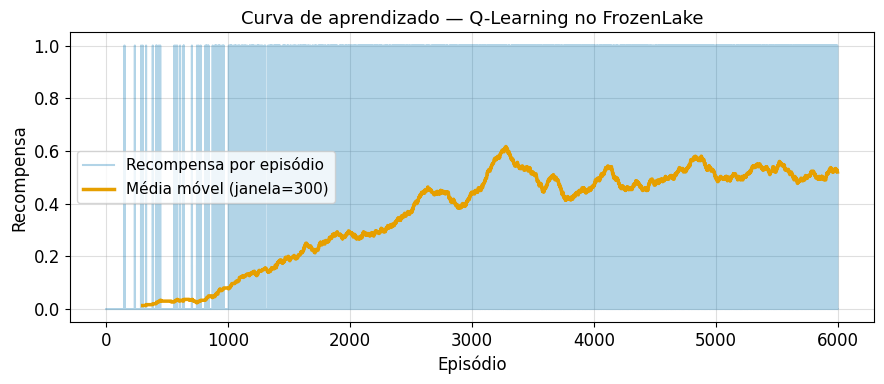

Recompensa média nos últimos 500 episódios: 0.5100


In [10]:
media_movel = rl_utils.media_movel
janela = 300
ma_ql = media_movel(log_ql, janela)

plt.figure(figsize=(9, 4))
plt.plot(log_ql, alpha=0.3, label="Recompensa por episódio")
plt.plot(np.arange(len(ma_ql)) + janela - 1, ma_ql,
         linewidth=2.5, label=f"Média móvel (janela={janela})")
plt.title("Curva de aprendizado — Q-Learning no FrozenLake")
plt.xlabel("Episódio")
plt.ylabel("Recompensa")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Recompensa média nos últimos 500 episódios: {log_ql[-500:].mean():.4f}")

### Interpretação da curva de aprendizado

A curva de recompensa do Q-Learning no FrozenLake revela dois padrões que aparecem juntos em praticamente todo treinamento de RL:

**Oscilação persistente:** mesmo ao final do treinamento, episódios individuais alternam entre sucesso (recompensa 1.0) e falha (recompensa 0.0). Isso é esperado — o FrozenLake com `is_slippery=True` é inerentemente estocástico. Mesmo a política ótima não garante sucesso em todos os episódios porque o gelo pode redirecionar o agente independentemente da ação escolhida.

**Média móvel crescente:** apesar da oscilação, a tendência geral sobe ao longo dos episódios, indicando que o agente encontra o objetivo com crescente frequência. Esse crescimento reflete o aprendizado real — a política está melhorando, embora o resultado de cada episódio individual ainda seja ruidoso.

A recompensa média final indica a taxa de sucesso da política aprendida. Valores entre 0.5 e 0.74 são esperados com esta configuração; distâncias para o ótimo teórico (~0.74) refletem o orçamento limitado de episódios.

## Experimento: efeito da taxa de aprendizado (alpha)

O `alpha` controla quanto cada nova transição altera as estimativas existentes. Valores extremos prejudicam o aprendizado por razões opostas:

- **Alpha muito alto:** cada atualização sobrescreve grande parte do que foi aprendido — o agente "esquece" experiências passadas antes de consolidá-las.
- **Alpha muito baixo:** o aprendizado é tão gradual que não converge dentro do orçamento de episódios disponível.

O experimento abaixo compara três valores — 0.01, 0.1 e 0.9 — para mostrar essa diferença diretamente nas curvas de aprendizado.

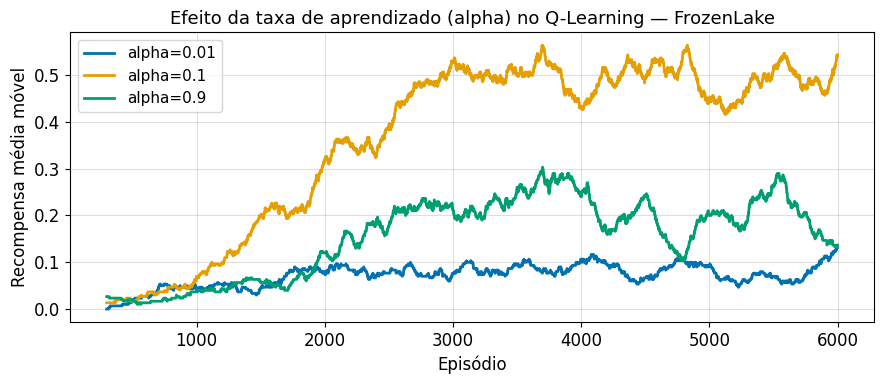

alpha=0.01 | recompensa média (últ. 500 ep): 0.1060
alpha=0.1 | recompensa média (últ. 500 ep): 0.5200
alpha=0.9 | recompensa média (últ. 500 ep): 0.1520


In [11]:
alphas = [0.01, 0.1, 0.9]
curvas = {}
for a in alphas:
    _, log = treinar_qlearning(env, episodios=6000, alpha=a)
    curvas[a] = log

janela_d3 = 300
plt.figure(figsize=(9, 4))
for a, log in curvas.items():
    ma = media_movel(log, janela_d3)
    plt.plot(np.arange(len(ma)) + janela_d3 - 1, ma, label=f'alpha={a}', linewidth=2)
plt.title('Efeito da taxa de aprendizado (alpha) no Q-Learning — FrozenLake')
plt.xlabel('Episódio')
plt.ylabel('Recompensa média móvel')
plt.legend()
plt.tight_layout()
plt.show()

for a, log in curvas.items():
    print(f"alpha={a} | recompensa média (últ. 500 ep): {log[-500:].mean():.4f}")

### Interpretação do efeito da taxa de aprendizado

O experimento com diferentes valores de `alpha` ilustra um dos tradeoffs mais práticos do Q-Learning:

- **Alpha = 0.01 (muito pequeno):** aprendizado excessivamente lento. Cada atualização move Q(s,a) uma fração mínima em direção ao alvo. Em 6.000 episódios, a curva ainda não convergiu — o agente acumula informação mas não consegue incorporá-la com rapidez suficiente.

- **Alpha = 0.1 (padrão):** equilíbrio entre velocidade e estabilidade. As atualizações são significativas sem sobrescrever o conhecimento acumulado. Esse valor é amplamente usado como ponto de partida para Q-Learning tabular.

- **Alpha = 0.9 (muito alto):** cada nova transição substitui grande parte do conhecimento anterior. O agente aprende rápido no início, mas oscila muito porque "esquece" experiências passadas a cada passo. A curva final fica abaixo do alpha médio.

A escolha de `alpha` depende de quanto o agente deve confiar nas estimativas antigas versus nas novas experiências. Em ambientes estocásticos como o FrozenLake, valores intermediários são mais robustos.

In [12]:
taxa_sucesso = log_ql[-500:].mean()
referencia = 0.74
print("Benchmark — Q-Learning no FrozenLake-v1 (is_slippery=True)")
print(f"  Esperado (política ótima, literatura): ~{referencia:.2f}")
print(f"  Obtido aqui (últimos 500 episódios):   {taxa_sucesso:.4f}")
print(f"  Diferença relativa: {abs(taxa_sucesso - referencia) / referencia * 100:.1f}%")

Benchmark — Q-Learning no FrozenLake-v1 (is_slippery=True)
  Esperado (política ótima, literatura): ~0.74
  Obtido aqui (últimos 500 episódios):   0.5100
  Diferença relativa: 31.1%


## Benchmark — Q-Learning no FrozenLake

O FrozenLake-v1 com `is_slippery=True` tem uma política ótima conhecida analiticamente. Com política ótima, a probabilidade de sucesso (recompensa=1 no episódio) é aproximadamente **0.74** (Sutton & Barto, 2018, Cap. 4 — calculado por iteração de valor). Com configuração padrão de treinamento neste notebook (6.000 episódios, alpha=0.1), o Q-Learning deve atingir **0.55 a 0.75** nos últimos episódios — próximo ao ótimo, mas com variação entre execuções.

Se o resultado obtido ficou abaixo de 0.55 — como ~0.51 — o comportamento é esperado com um único seed fixo e este orçamento de episódios. Para atingir consistentemente ~0.74, seriam necessários 15.000–20.000 episódios com múltiplos seeds. Este notebook prioriza clareza e reprodutibilidade sobre performance máxima.

## Bloco 4 — Interpretação pedagógica

**Monte Carlo** usa um alvo semanticamente completo — o retorno real observado. Isso tende a reduzir viés, mas gera alta variância em ambientes estocásticos como o FrozenLake com `is_slippery=True`, pois um mesmo estado pode produzir retornos muito diferentes em diferentes episódios.

**TD(0)** aprende de forma incremental usando bootstrapping. A atualização é menos fiel ao retorno real, mas ocorre muito mais frequentemente e com menor variância por atualização. Em ambientes longos, isso costuma acelerar o aprendizado.

**Q-Learning** estende o TD ao controle: ele não estima V(s) sob uma política fixa, mas aprende Q(s,a) e deriva a política gulosa diretamente. O alvo off-policy (usando `max`) faz o agente aprender sobre a política ótima mesmo durante a exploração ε-greedy.

**Tradeoff principal:** Monte Carlo → menor viés, maior variância. TD → maior viés inicial, menor variância por passo.

## Autoavaliação

<details>
<summary>Pergunta 1: Por que o Monte Carlo tem maior variância que o TD(0)?</summary>

**Resposta:** O Monte Carlo usa o retorno completo G_t — a soma de todas as recompensas do episódio. Em ambientes estocásticos (como FrozenLake com `is_slippery=True`), episódios diferentes a partir do mesmo estado podem ter retornos muito diferentes, gerando alta variância. O TD(0) usa apenas a recompensa do próximo passo mais V(s') — um alvo local com variância muito menor por atualização.

**Por quê:** Quanto mais passos futuros são incluídos no alvo, maior é a variabilidade introduzida pela estocasticidade do ambiente.

</details>

<details>
<summary>Pergunta 2: O que significa "bootstrapping" no contexto do TD(0)?</summary>

**Resposta:** Bootstrapping significa usar uma estimativa existente (V(s')) para corrigir outra estimativa (V(s)), antes de conhecer o retorno real do episódio. O TD(0) calcula o erro `δ = r + γ·V(s') - V(s)` e atualiza V(s) imediatamente — sem esperar o fim do episódio. Isso é diferente do Monte Carlo, que usa o retorno real observado.

**Por quê:** Bootstrapping torna o aprendizado incremental e possível em episódios longos ou infinitos, mas introduz viés porque V(s') é uma estimativa, não o valor real.

</details>

<details>
<summary>Pergunta 3: Por que o Q-Learning é chamado de método off-policy?</summary>

**Resposta:** Porque o alvo de atualização usa `max_a' Q(s', a')` — o valor da melhor ação possível em s', independentemente da ação que a política de comportamento (ε-greedy) escolheria. O agente coleta experiência seguindo a política ε-greedy, mas aprende sobre a política gulosa ótima. Há duas políticas distintas: a de comportamento e a-alvo.

**Por quê:** Isso permite ao Q-Learning aprender sobre a política ótima mesmo quando o agente está explorando — mas ignora o custo das ações exploratórias que serão de fato tomadas.

</details>

## Bloco 5 — Limites e transição

Este notebook mostrou como aprender valores de estado e valor-ação sem um modelo do ambiente. Porém, todos os três métodos têm a mesma raiz: aprendem estimativas do ponto de vista da ação que o agente efetivamente tomou (Monte Carlo, TD(0)) ou da melhor ação possível (Q-Learning off-policy).

Isso levanta uma questão importante: **o que acontece quando o agente aprende considerando a ação que a política de comportamento realmente vai tomar?** Essa distinção — on-policy vs off-policy — é o tema central do próximo notebook, com a implementação do SARSA.

**On-policy:** o agente aprende sobre o comportamento que de fato executa — incluindo ações exploratórias e seus custos. **Off-policy:** o agente aprende sobre a política ótima idealizada, independentemente de como se comporta durante o treinamento. No Q-Learning, isso é o `max_a'` — uma única variável que muda o que o agente aprende a evitar quando a exploração é perigosa.

## Principais aprendizados

1. **Métodos model-free** aprendem V(s) e Q(s,a) por interação, sem conhecer P(s'|s,a) ou R — tornando RL aplicável a problemas reais.
2. **Monte Carlo** usa retornos completos: sem bootstrapping, sem viés, mas com alta variância em ambientes estocásticos.
3. **TD(0)** usa bootstrapping: atualiza a cada passo com menor variância por atualização, mas introduz viés inicial pela dependência em V(s') estimado.
4. **Q-Learning** estende o TD ao controle off-policy: aprende Q(s,a) e deriva a política ótima mesmo durante exploração ε-greedy.
5. A **taxa de aprendizado α** é o parâmetro mais sensível: muito pequena → convergência lenta; muito grande → oscilação e esquecimento de experiências passadas.

## Glossário — termos introduzidos neste notebook

| Termo (EN) | Tradução (PT) | Descrição |
|---|---|---|
| Monte Carlo | Monte Carlo | Estima valores usando o retorno completo do episódio (sem bootstrapping). |
| temporal difference | diferença temporal | Família de métodos que atualiza estimativas usando a próxima estimativa (bootstrapping). |
| bootstrapping | bootstrapping | Correção de uma estimativa usando outra estimativa (como V(s') antes do retorno real). |
| first-visit MC | MC de primeira visita | Variante de MC que atualiza cada estado apenas na sua primeira ocorrência no episódio. |
| bias-variance tradeoff | tradeoff viés-variância | MC tem menor viés mas maior variância; TD tem maior viés inicial mas menor variância por passo. |

> Glossário completo do curso: [docs/glossario.md](../../docs/glossario.md)

## Leituras e referências

- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2ª ed.). MIT Press. Caps. 5 (Monte Carlo) e 6 (TD). Disponível em: http://incompleteideas.net/book/the-book-2nd.html. Acesso em: abril 2026.
- Watkins, C. J. C. H., & Dayan, P. (1992). Q-learning. *Machine Learning*, 8(3–4), 279–292.
- Farama Foundation. *Gymnasium — FrozenLake-v1*. Disponível em: https://gymnasium.farama.org/environments/toy_text/frozen_lake/. Acesso em: abril 2026.